# Kuvantunnistus omilla kuvilla - CNN

## Datan ymmärrys
Datasetti sisältää yhtensä 478 kuvaa ja kuusi luokkaa. Kuvien luokat ja niiden kuvamäärät ovat seuraavat:
- Omena: 52 kuvaa
- Avokaado: 50 kuvaa
- Banaani: 104 kuvaa
- Viinirypäle: 66 kuvaa
- Kiivi: 50 kuvaa
- Appelsiini: 158 kuvaa

## Datan esikäsittely
Kuvadata ladataan Dataset-olioksi `tf.keras.preprocessing.image_dataset_from_directory`-funktiolla. Funktion parametreina annetaan kuvien polku, kuvien koko, eräkoko, labelien muoto ja sekoitus, jolloin data sekoitetaan ja kaikki kuvat eivät ole peräkkäin samasta luokasta. 

Datasetti normalisoidaan jakamalla kuvat 255:llä. Datasetti jaetaan koulutus-, validointi- ja testidatasetteihin 70%, 15% ja 15% suhteessa.

In [6]:
import tensorflow as tf
import numpy as np
from numpy.f2py.crackfortran import verbose
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom
import random

batch_size = 32
img_size = (224, 224)
split_ratio = [0.7, 0.15, 0.15] 

# Ladataan datasetti
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

class_names = dataset.class_names

# Normalisoidaan kuvat
dataset = dataset.map(lambda x, y: (x / 255.0, y))

dataset_size = len(dataset)


train_size = int(split_ratio[0] * dataset_size)
val_size = int(split_ratio[1] * dataset_size)

train_dataset = dataset.take(train_size)
validation_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)


# Tarkistetaan datasetin koko
print(f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")


Found 478 files belonging to 6 classes.
Train batches: 10, Validation batches: 2, Test batches: 3


In [7]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    data_augmentation,
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10, verbose=0)

/home/stefu/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

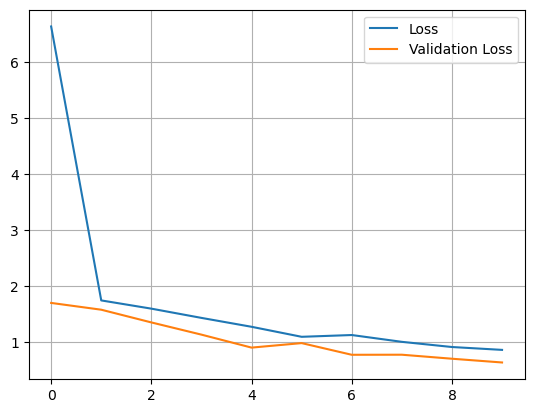

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [9]:
score = model.evaluate(test_dataset, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.5838831663131714
Test accuracy: 0.7553191781044006


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


2025-04-01 13:01:03.973373: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


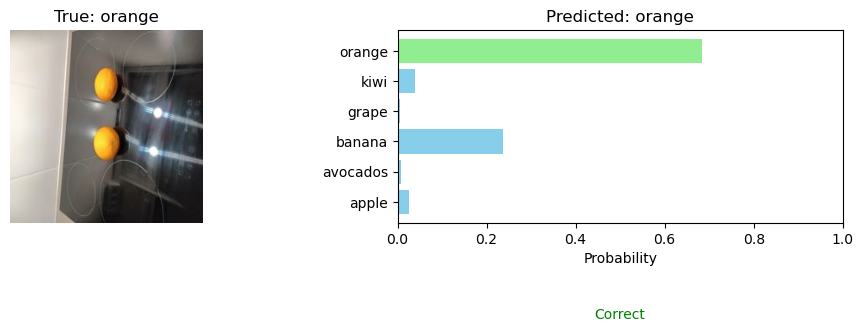

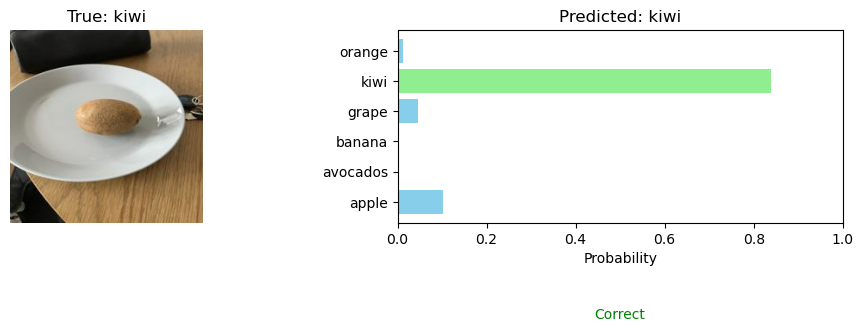

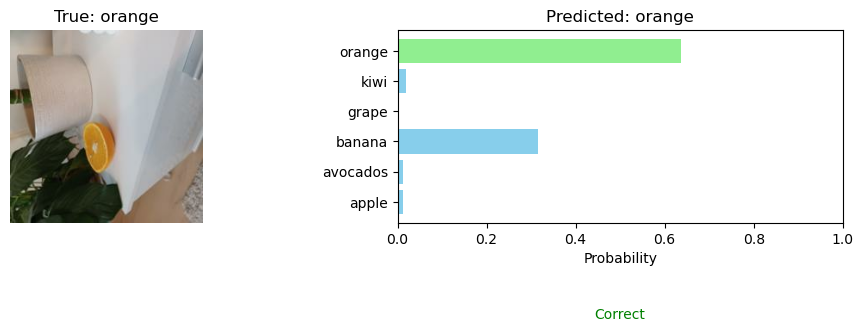

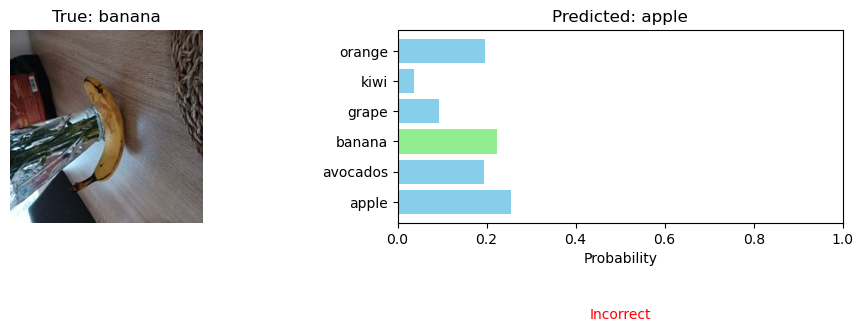

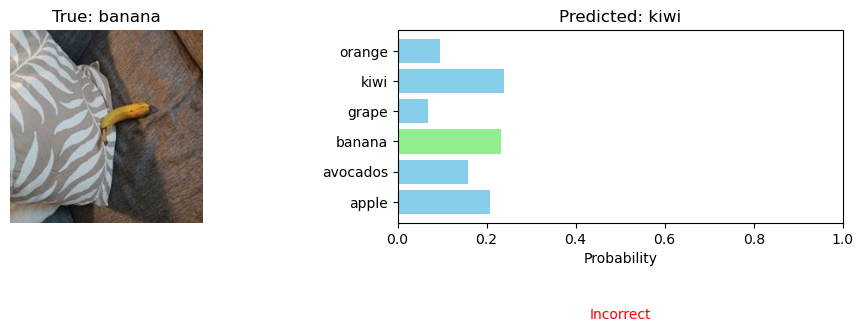

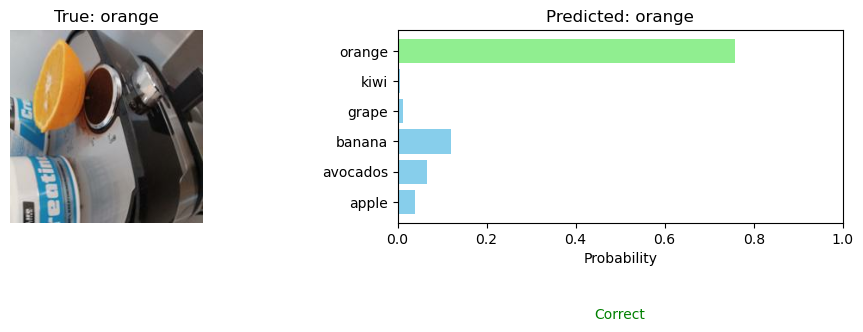

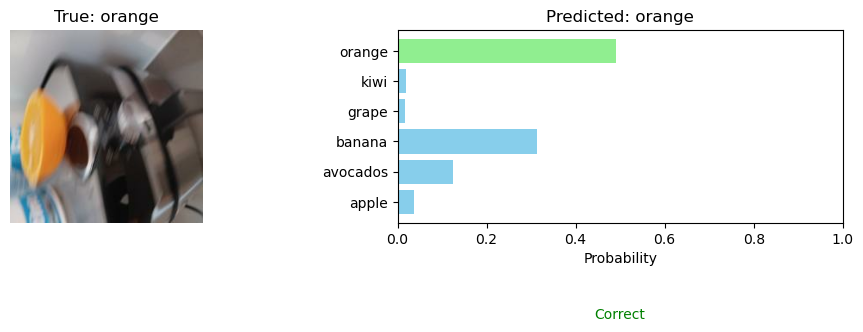

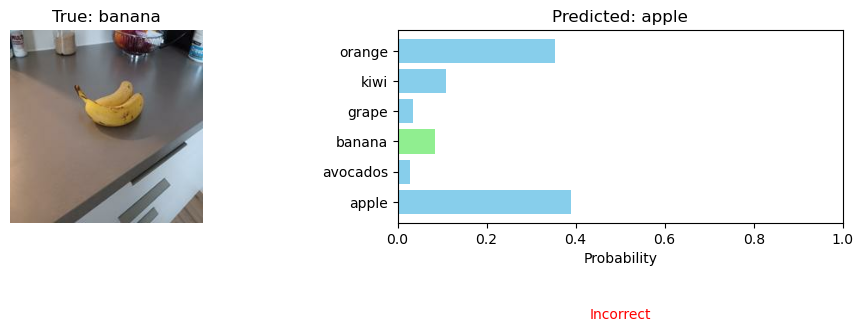

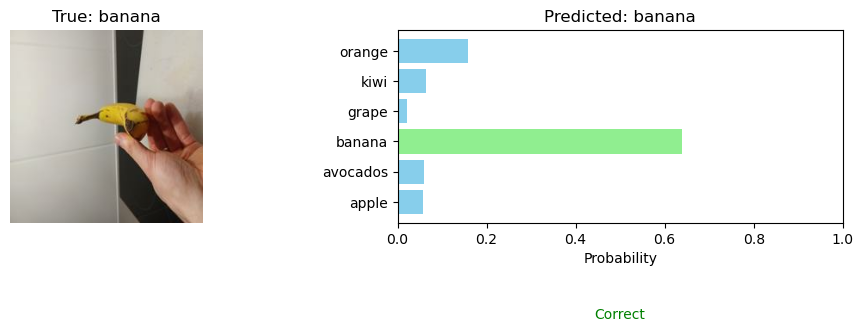

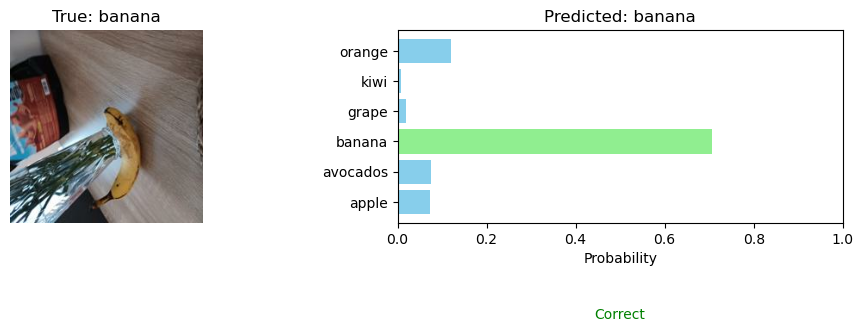

In [10]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)

def plot_images(model):
    y_pred = []
    x_images = []
    y_true = []

    for images, labels in test_dataset:
        y_pred.extend(model.predict(images, batch_size=32))
        x_images.extend(images.numpy())
        y_true.extend(labels.numpy())

    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    x_images = np.array(x_images)

    num_samples = 10
    random_indices = random.sample(range(len(x_images)), num_samples)

    for i in random_indices:
        plt.figure(figsize=(10, 4))

        # Display image
        plt.subplot(1, 2, 1)
        plt.imshow((x_images[i] * 255).astype("uint8"))
        true_class = class_names[np.argmax(y_true[i])]
        plt.title(f"True: {true_class}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        pred_prob = y_pred[i]
        predicted_class = class_names[np.argmax(pred_prob)]

        colors = ['lightgreen' if (class_names[idx] == true_class) else 'skyblue'
                  for idx in range(len(class_names))]

        plt.barh(class_names, pred_prob, color=colors)
        plt.xlabel('Probability')
        plt.title(f"Predicted: {predicted_class}")
        plt.xlim([0, 1])

        if predicted_class != true_class:
            plt.text(0.5, -0.5, "Incorrect", color='red',
                    ha='center', transform=plt.gca().transAxes)
        else:
            plt.text(0.5, -0.5, "Correct", color='green',
                    ha='center', transform=plt.gca().transAxes)

        plt.tight_layout()
        plt.show()

plot_images(model)

# Kuvantunnistus omilla kuvilla - VGG16 Assisted

In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model  # Changed from Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg16_base.trainable = False

x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dense(128, activation='relu')(x)

x = Dropout(0.2)(x)
predictions = Dense(6, activation='softmax')(x)

model2 = Model(inputs=vgg16_base.input, outputs=predictions)

model2.compile(optimizer='adam',
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, epochs=10, verbose=0)


I0000 00:00:1743501665.637477    1104 service.cc:152] XLA service 0x7fecec2a1da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743501665.637512    1104 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2025-04-01 13:01:05.685730: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-01 13:01:22.792689: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_702', 188 bytes spill stores, 188 bytes spill loads

2025-04-01 13:01:22.797483: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1629', 56 bytes spill stores, 56 bytes spill loads

2025-04-01 13:01:23.054772: 

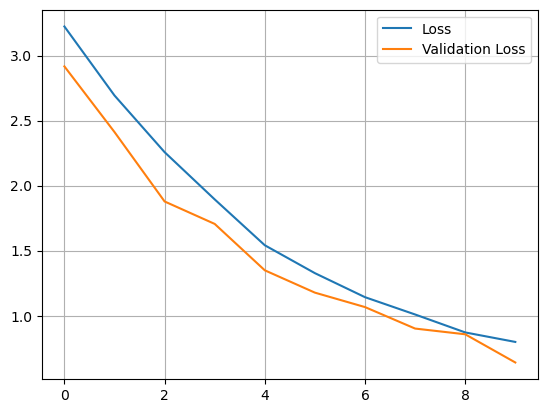

In [12]:
plt.plot(history2.history["loss"], label="Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [13]:
model2_test_score = model2.evaluate(test_dataset, verbose=0)
print('Test loss:', model2_test_score[0])
print('Test accuracy:', model2_test_score[1])

2025-04-01 13:01:36.488178: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 4 bytes spill stores, 4 bytes spill loads

2025-04-01 13:01:36.567994: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_231', 200 bytes spill stores, 200 bytes spill loads

2025-04-01 13:01:36.694732: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_262', 4 bytes spill stores, 4 bytes spill loads

2025-04-01 13:01:37.250726: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_255', 12 bytes spill stores, 12 bytes spill loads



Test loss: 0.6952652335166931
Test accuracy: 0.9468085169792175


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7317 - loss: 0.7471 

Test Set Accuracy: 74.47%

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step


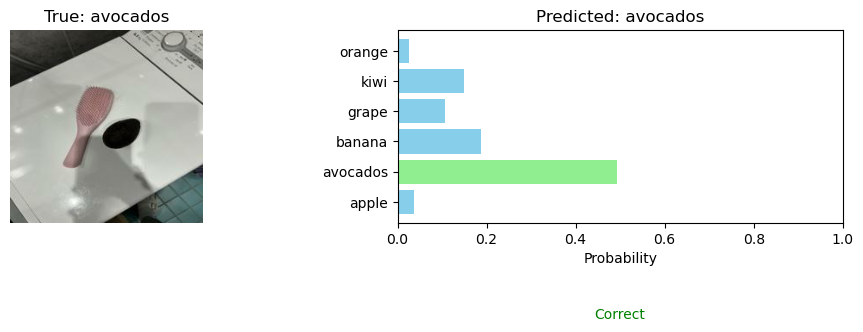

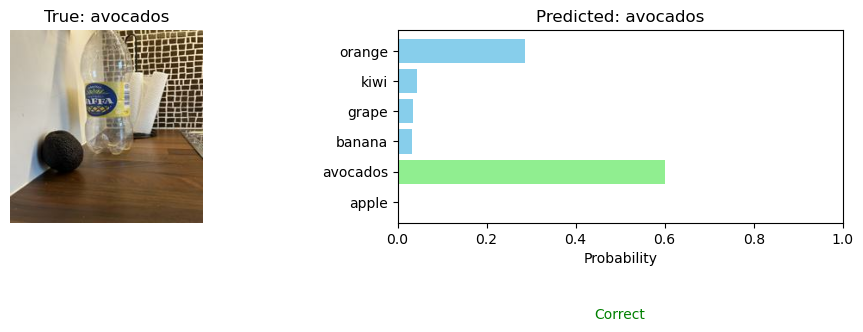

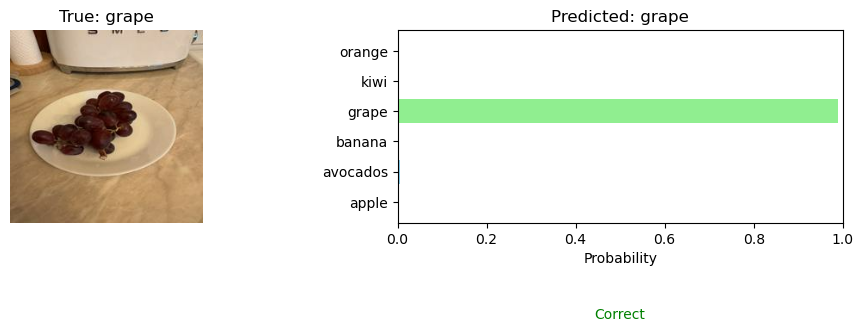

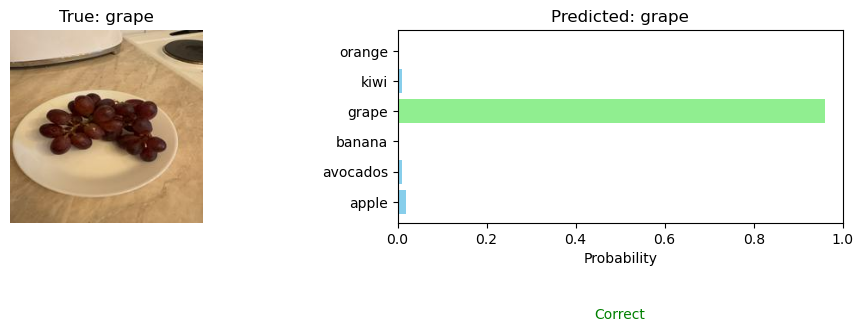

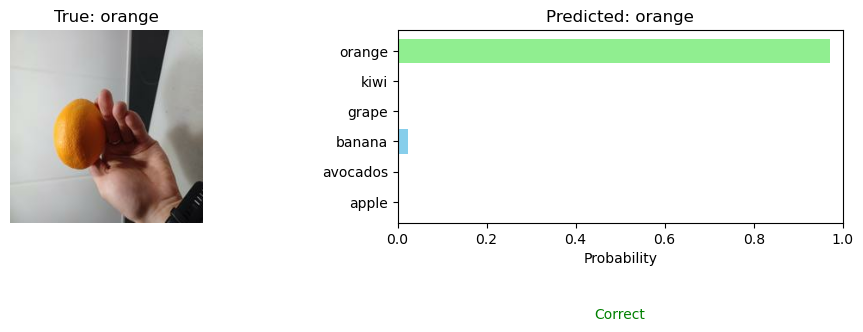

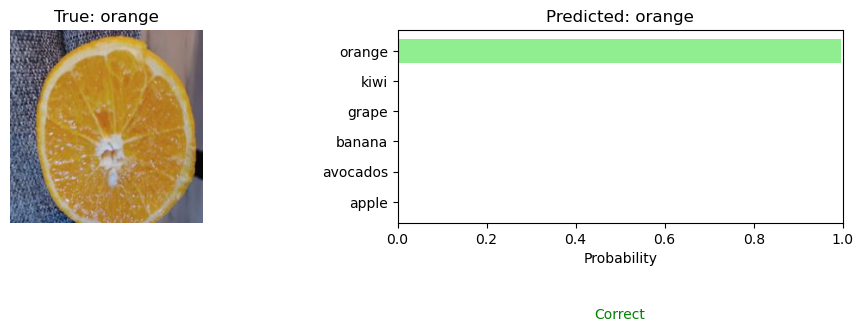

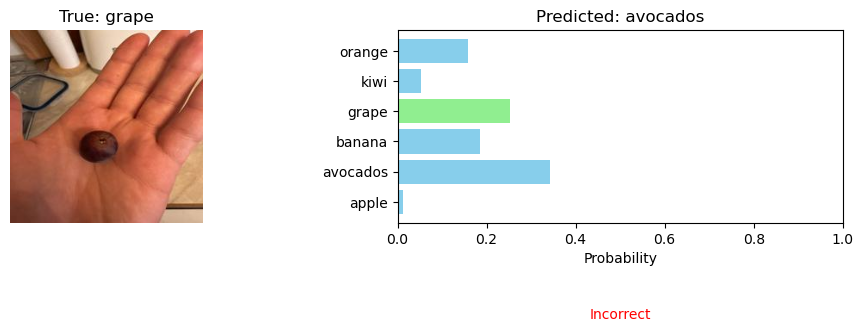

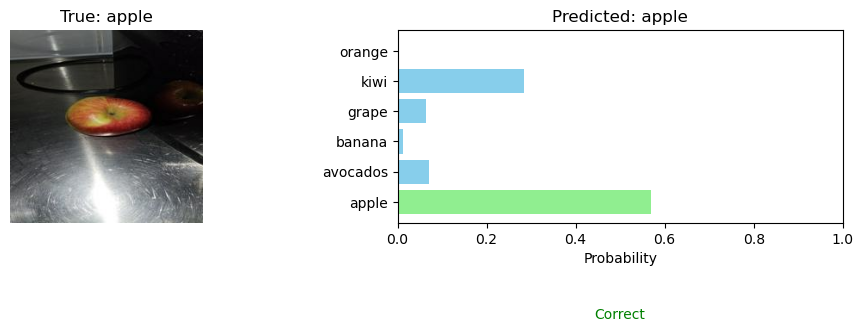

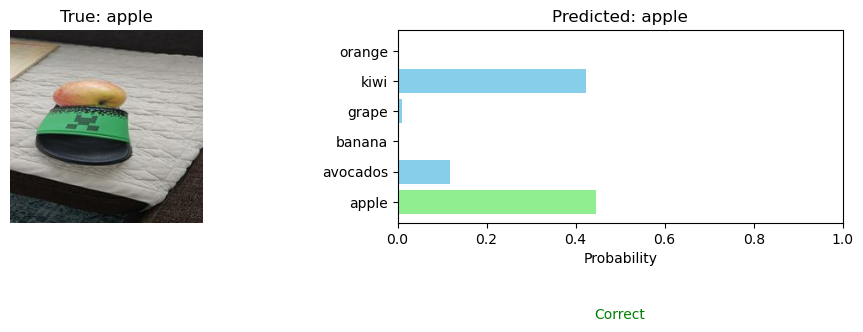

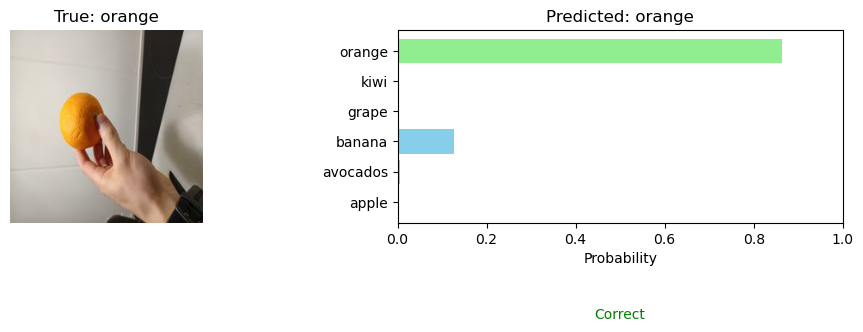

In [14]:
import matplotlib.pyplot as plt
import numpy as np

test_loss, test_acc = model.evaluate(test_dataset)
print(f"\nTest Set Accuracy: {test_acc*100:.2f}%\n")

plot_images(model2)